In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1. Učitavanje podataka
# ----------------------------
# ISPRAVAK parsiranja minuta: minute tipa "1,641" zapisane su s tisućicom, pa je
# nužan thousands=",". Bez toga su takve vrijednosti postajale NaN i igrači s
# najviše odigranih minuta (prvotimci) tiho su ispadali iz uzorka.
df = pd.read_csv("igraci.csv", thousands=",")

# Pomoćna funkcija: robusna pretvorba u broj.
# (U CSV-u se javljaju vrijednosti tipa "01.04" ili "1,641" pa ih čistimo.)
def to_num(col):
    return pd.to_numeric(df[col].astype(str).str.replace(",", "", regex=False),
                         errors="coerce")

# ----------------------------
# 2. Filtriranje na DEFINIRANI UZORAK: top-5 europskih liga, polusezona 2025/26
# ----------------------------
# NAPOMENA: ovo NIJE ispravak greške u podacima, nego definicija uzorka rada.
# Promatramo pet najjačih europskih liga; igrači izvan njih (npr. iz HNL-a)
# prirodno ispadaju, kao i eventualni ponovljeni redci zaglavlja u CSV-u.
top5_ligas = ["eng Premier League", "es La Liga", "it Serie A",
              "de Bundesliga", "fr Ligue 1"]
df = df[df["Comp"].isin(top5_ligas)].reset_index(drop=True)

# Minimalna minutaža: per-90 vrijednosti su stabilnije uz dovoljan uzorak minuta.
df["Min"] = to_num("Min")
df = df[df["Min"] >= 450].reset_index(drop=True)

# ----------------------------
# 3. Izgradnja čistog, dosljedno PER-90 prostora značajki (9 značajki)
# ----------------------------
# Sve značajke mjere STIL igre (po 90 minuta), a ne obujam. Uklonjeni su:
#   - duplikati (ukupno vs per-90)  -> zadržana je per-90 razina,
#   - zbrojevi (G+A, npxG+xAG ...)  -> linearne kombinacije drugih značajki,
#   - penali (PK, PKatt)            -> šum za stil igre.
# Stvarna i očekivana strana simetrično su BEZ penala (G-PK i npxG).
# VAŽNO: u ovom CSV-u su PrgC/PrgP/PrgR/CrdY/CrdR već per-90 (provjereno na
# podacima), pa se uzimaju kako jesu — bez dijeljenja sa "90s".
feature_map = {
    "G-PK_90": "G-PK.1",   # ne-penalski golovi / 90
    "Ast_90":  "Ast.1",    # asistencije / 90
    "xAG_90":  "xAG.1",    # očekivane asistencije (xAG) / 90
    "npxG_90": "npxG.1",   # ne-penalski očekivani golovi (npxG) / 90
    "PrgC_90": "PrgC",     # progresivna vođenja lopte / 90
    "PrgP_90": "PrgP",     # progresivni dodavanja / 90
    "PrgR_90": "PrgR",     # progresivna primanja lopte / 90
    "CrdY_90": "CrdY",     # žuti kartoni / 90
    "CrdR_90": "CrdR",     # crveni kartoni / 90
}
for new_name, src in feature_map.items():
    df[new_name] = to_num(src)

feature_cols = list(feature_map.keys())

# ----------------------------
# 4. Metapodaci i nedostajuće vrijednosti
# ----------------------------
metadata_cols = ["Player", "Pos", "Squad", "Comp", "Nation", "Age"]
metadata_cols = [c for c in metadata_cols if c in df.columns]
df = df[metadata_cols + feature_cols].copy()
df[feature_cols] = df[feature_cols].fillna(0)

# ----------------------------
# 5. Standardizacija (z-score) PRIJE bilo kakvog računanja sličnosti
# ----------------------------
# Sve metrike sličnosti rade na ovim standardiziranim značajkama.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Konačni oblik skupa podataka:", df_scaled.shape)
print("Broj značajki:", len(feature_cols))
print("Značajke:", feature_cols)

In [ ]:
# ----------------------------
# 2. Podjela igrača po skupinama pozicija
# ----------------------------
def get_position_group(pos):
    """
    Preslikava detaljne oznake pozicija u široke skupine pozicija.
    Rješava igrače s više pozicija uzimajući primarnu (prvu) poziciju.
    """
    if pd.isna(pos):
        return 'UNKNOWN'

    # Uzmi primarnu poziciju (prvu navedenu)
    primary_pos = pos.split(',')[0].strip()

    # Preslikavanje u glavne skupine
    if 'GK' in primary_pos:
        return 'GK'
    elif any(p in primary_pos for p in ['CB', 'LB', 'RB', 'WB', 'DF']):
        return 'DEF'
    elif any(p in primary_pos for p in ['DM', 'CM', 'AM', 'MF']):
        return 'MID'
    elif any(p in primary_pos for p in ['FW', 'LW', 'RW', 'ST', 'CF']):
        return 'FWD'
    else:
        # Rezervna opcija
        if 'DF' in pos or 'B' in primary_pos:
            return 'DEF'
        elif 'MF' in pos or 'M' in primary_pos:
            return 'MID'
        elif 'FW' in pos or 'W' in primary_pos:
            return 'FWD'
        return 'UNKNOWN'

# Primjena grupiranja pozicija
df_scaled['PosGroup'] = df_scaled['Pos'].apply(get_position_group)

# ----------------------------
# Isključivanje golmana (GK) iz cijele analize
# ----------------------------
# Skup značajki je čisto OFENZIVAN (golovi, xG, asistencije, progresije, kartoni).
# Za golmane su te značajke gotovo nula: unutar GK grupe čak 3 značajke
# (G-PK_90, PrgC_90, PrgR_90) imaju NULTU varijancu, pa korelacijska matrica M
# (za soft_cosine) nije valjana, a sličnost je degenerirana (prosj. kosinus ~0.91 —
# golmani su praktički neraspoznatljivi). Isključenjem GK opseg postaje dosljedan
# postojećem K-Means/t-SNE dijelu (FWD/MID/DEF). Golmani se u radu navode kao
# LIMITACIJA (nedostatak golmanskih značajki), ne kao greška.
df_scaled = df_scaled[df_scaled['PosGroup'] != 'GK'].reset_index(drop=True)

print("Distribucija grupa pozicija (bez golmana):")
print(df_scaled['PosGroup'].value_counts())

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# ----------------------------
# 3. Skupovi podataka po pozicijskim grupama
# ----------------------------
# Za SVAKU grupu čuvamo:
#   - 'std_features': standardizirane značajke (NA NJIMA se računaju SVE metrike),
#   - 'pca_features': PCA projekcija (koristi se ISKLJUČIVO za BASELINE: PCA + kosinus).
position_data = {}

all_pos_groups = df_scaled['PosGroup'].unique().tolist()
print(f"Pronađene skupine pozicija: {all_pos_groups}")

for pos_group in all_pos_groups:
    df_pos = df_scaled[df_scaled['PosGroup'] == pos_group].copy().reset_index(drop=True)

    if len(df_pos) == 0:
        print(f"Upozorenje: Nema pronađenih igrača za {pos_group}")
        continue

    # Standardizirane značajke za ovu grupu (pre-PCA) — temelj svih metrika.
    std_features = df_pos[feature_cols].values

    # PCA samo za baseline referencu (zadržavamo 95% varijance).
    pca = PCA(n_components=0.95, random_state=42)
    pca_features = pca.fit_transform(std_features)

    print(f"\n{pos_group}: {len(df_pos)} igrača, {len(feature_cols)} značajki "
          f"(baseline PCA: {pca.n_components_} komponenti)")

    position_data[pos_group] = {
        'df': df_pos,
        'features': feature_cols,
        'std_features': std_features,      # za cosine/euclidean/dot_product/soft_cosine
        'pca_features': pca_features,      # za baseline (PCA + kosinus)
        'n_features': len(feature_cols),
        'pca_components': pca.n_components_,
    }

print("\n" + "=" * 50)
print(f"Skupovi podataka po pozicijama stvoreni: {list(position_data.keys())}")
print(f"Ukupan broj igrača: {sum(len(d['df']) for d in position_data.values())}")

In [ ]:
# ----------------------------
# 4. BASELINE: kosinusna sličnost na PCA značajkama (referenca za usporedbu)
# ----------------------------
# Ovo je POLAZIŠNA metoda iz izvornog projekta (PCA + kosinus). Zadržavamo je
# odvojeno kao referentnu točku spram koje uspoređujemo četiri "čiste" metrike
# (koje rade na standardiziranim značajkama, bez PCA).
from sklearn.metrics.pairwise import cosine_similarity

for pos_group, data in position_data.items():
    data['baseline_similarity'] = cosine_similarity(data['pca_features'])
    # Alias radi unatražne kompatibilnosti sa starijim ćelijama (uklanja se u Fazi 4).
    data['similarity_matrix'] = data['baseline_similarity']
    print(f"{pos_group}: baseline matrica sličnosti {data['baseline_similarity'].shape} "
          f"(PCA + kosinus)")

## Faza 2: Metrike sličnosti

U ovom dijelu definiramo **četiri metrike sličnosti** koje ćemo međusobno usporediti.
Za razliku od baseline pristupa (PCA + kosinus), sve četiri metrike rade izravno na
**standardiziranim značajkama prije PCA**, i to **unutar pozicijske grupe** svakog igrača:

1. **`cosine`** — kosinusna sličnost; mjeri sličnost *smjera* profila (stil), neovisno o magnitudi.
2. **`euclidean`** — euklidska *udaljenost*; manja vrijednost znači sličnijeg igrača (rangira se uzlazno).
3. **`dot_product`** — nenormalizirani skalarni produkt; uz smjer nagrađuje i *intenzitet* značajki.
4. **`soft_cosine`** — soft-kosinus s matricom sličnosti značajki **M** (Pearsonova korelacija
   značajki, računata unutar svake pozicijske grupe); dopušta da povezane značajke doprinose zajednički.

Funkcija `find_similar_players(player_name, metric=...)` jedinstveno opslužuje sve metrike i
zadržava postojeće filtre (dob, klub, liga).

In [ ]:
# ----------------------------
# 5. Metrike sličnosti (čiste funkcije)
# ----------------------------
# Sve metrike rade na STANDARDIZIRANIM značajkama (pre-PCA), unutar pozicijske grupe.
# Konvencija: funkcija prima matricu X (redak = igrač) i indeks ciljnog igrača te
# vraća vektor rezultata prema SVIM igračima u grupi.
#   - cosine, dot_product, soft_cosine -> VEĆE = sličnije (rangiranje silazno)
#   - euclidean                        -> MANJE = sličnije (rangiranje uzlazno)

def cosine(X, idx):
    """Kosinusna sličnost ciljnog retka `idx` prema svim retcima matrice X.

    Mjeri sličnost SMJERA vektora (profil/stil igre), neovisno o magnitudi.
    Veće = sličnije.
    """
    target = X[idx]
    norms = np.linalg.norm(X, axis=1) * np.linalg.norm(target)
    norms[norms == 0] = 1e-12
    return (X @ target) / norms


def euclidean(X, idx):
    """Euklidska udaljenost ciljnog retka `idx` prema svim retcima matrice X.

    Mjeri apsolutnu razliku u standardiziranom prostoru značajki (i smjer i intenzitet).
    MANJE = sličnije -> pri rangiranju se sortira UZLAZNO.
    """
    diff = X - X[idx]
    return np.sqrt(np.sum(diff ** 2, axis=1))


def dot_product(X, idx):
    """Nenormalizirani skalarni produkt ciljnog retka `idx` prema svim retcima.

    Za razliku od kosinusa NE poništava magnitudu, pa nagrađuje igrače koji su
    izraženi (visoke vrijednosti) u istim značajkama kao i cilj. Veće = sličnije.
    """
    return X @ X[idx]


def soft_cosine(X, idx, M):
    """Soft-kosinusna sličnost ciljnog retka `idx` prema svim retcima.

        sim(a, b) = (aᵀ M b) / ( sqrt(aᵀ M a) · sqrt(bᵀ M b) )

    Klasični kosinus implicitno pretpostavlja da su značajke međusobno ORTOGONALNE
    (M = I). Soft-kosinus tu pretpostavku opušta uvođenjem matrice sličnosti
    ZNAČAJKI M (d×d): povezane značajke tada doprinose zajednički.

    Zašto M = korelacijska matrica značajki:
      Za M uzimamo Pearsonovu korelacijsku matricu standardiziranih značajki,
      računatu UNUTAR svake pozicijske grupe. Značajke koje mjere srodan aspekt
      igre (npr. npxG_90 i G-PK_90, ili PrgC_90 i PrgR_90) jako su korelirane, pa
      ih soft-kosinus tretira kao djelomično ISTU dimenziju umjesto kao neovisne
      osi — čime ublažava preklapanje informacija među značajkama. Korelacijska
      matrica je k tome pozitivno semidefinitna (Gramova matrica standardiziranih
      značajki), pa je gornja formula valjan (semi-)unutarnji produkt i izraz je
      dobro definiran. Veće = sličnije.
    """
    target = X[idx]
    Mb = M @ target
    num = X @ Mb                                    # aᵀ M b za svaki redak a
    aMa = np.einsum('ij,jk,ik->i', X, M, X)         # aᵀ M a za svaki redak a
    bMb = float(target @ Mb)                        # bᵀ M b (skalar)
    denom = np.sqrt(np.clip(aMa, 1e-12, None)) * np.sqrt(max(bMb, 1e-12))
    return num / denom


# Registar metrika: ime -> specifikacija (funkcija, treba li M, smjer rangiranja).
METRICS = {
    'cosine':      {'fn': cosine,      'needs_M': False, 'ascending': False},
    'euclidean':   {'fn': euclidean,   'needs_M': False, 'ascending': True},
    'dot_product': {'fn': dot_product, 'needs_M': False, 'ascending': False},
    'soft_cosine': {'fn': soft_cosine, 'needs_M': True,  'ascending': False},
}

# ----------------------------
# 6. Matrica sličnosti značajki M za soft-kosinus (Pearson, UNUTAR svake grupe)
# ----------------------------
for pos_group, data in position_data.items():
    # rowvar=False -> korelacija MEĐU stupcima (značajkama), ne među igračima.
    M = np.corrcoef(data['std_features'], rowvar=False)
    M = np.nan_to_num(M, nan=0.0)   # zaštita ako bi neka značajka imala nultu varijancu
    data['M'] = M

print("Metrike spremne:", list(METRICS.keys()))
print("Matrica M (soft_cosine) izračunata po grupama; oblik za FWD:",
      position_data['FWD']['M'].shape)

In [ ]:
# ----------------------------
# 7. Pronalaženje sličnih igrača (jedinstvena funkcija za sve metrike)
# ----------------------------

def find_similar_players(player_name, metric='cosine', n_similar=10,
                         age_range=None, exclude_same_team=False,
                         exclude_same_league=False, verbose=True):
    """Pronađi najsličnije igrače zadanom igraču prema odabranoj metrici.

    Parametri
    ---------
    player_name : str
        Ime (ili dio imena) ciljnog igrača.
    metric : {'cosine', 'euclidean', 'dot_product', 'soft_cosine'}
        Metrika sličnosti. SVE rade na standardiziranim značajkama (pre-PCA),
        unutar pozicijske grupe ciljnog igrača.
    n_similar : int
        Koliko najsličnijih igrača vratiti.
    age_range : (min_age, max_age) ili None
        Filtar po dobi (godine iz stupca Age).
    exclude_same_team : bool
        Izbaci igrače iz istog kluba kao cilj.
    exclude_same_league : bool
        Izbaci igrače iz iste lige kao cilj.
    verbose : bool
        Ispiši informacije o ciljnom igraču i metrici.

    Vraća
    -----
    pandas.DataFrame
        Top-n sličnih igrača sa stupcem 'Score'. Za 'euclidean' je 'Score'
        udaljenost (manje = sličnije); za ostale metrike veće = sličnije.
    """
    if metric not in METRICS:
        raise ValueError(f"Nepoznata metrika '{metric}'. "
                         f"Dostupne: {list(METRICS.keys())}")
    if not position_data:
        print("Greška: position_data je prazan. Prvo pokrenite prethodne ćelije.")
        return None

    # --- pronalazak ciljnog igrača kroz sve pozicijske grupe ---
    target_pos_group = target_idx = target_info = None
    for pos_group, data in position_data.items():
        df_pos = data['df']
        matches = df_pos[df_pos['Player'].str.contains(player_name, case=False, na=False)]
        if len(matches) > 0:
            if len(matches) > 1 and verbose:
                print(f"Pronađeno više podudaranja za '{player_name}':")
                print(matches[['Player', 'Squad', 'Pos']].to_string())
                print("Koristi se prvo podudaranje.\n")
            target_pos_group = pos_group
            target_idx = matches.index[0]
            target_info = matches.iloc[0]
            break

    if target_pos_group is None:
        print(f"Igrač '{player_name}' nije pronađen u skupu podataka.")
        return None

    data = position_data[target_pos_group]
    df_pos = data['df']
    X = data['std_features']            # standardizirane značajke (pre-PCA)

    if verbose:
        print(f"Cilj: {target_info['Player']} | Pozicija: {target_info['Pos']} "
              f"(Grupa: {target_pos_group}) | Klub: {target_info['Squad']}")
        if 'Comp' in target_info.index:
            print(f"Liga: {target_info['Comp']} | Dob: {target_info.get('Age', 'n/a')}")
        print(f"Metrika: {metric}")
        print("-" * 60)

    # --- izračun rezultata prema odabranoj metrici ---
    spec = METRICS[metric]
    if spec['needs_M']:
        scores = spec['fn'](X, target_idx, data['M'])
    else:
        scores = spec['fn'](X, target_idx)

    results = df_pos.copy()
    results['Score'] = scores
    results = results[results.index != target_idx]   # makni samog ciljnog igrača

    # --- filtri (isti kao u izvornoj verziji) ---
    if exclude_same_team:
        results = results[results['Squad'] != target_info['Squad']]
    if exclude_same_league and 'Comp' in results.columns:
        results = results[results['Comp'] != target_info['Comp']]
    if age_range is not None and 'Age' in results.columns:
        min_age, max_age = age_range
        def extract_age(x):
            try:
                return int(str(x).split('-')[0])
            except (ValueError, TypeError):
                return None
        ages = results['Age'].apply(extract_age)
        results = results[ages.notna() & (ages >= min_age) & (ages <= max_age)]

    # --- rangiranje: uzlazno za euklidsku udaljenost, inače silazno ---
    results = results.sort_values('Score', ascending=spec['ascending'])
    top = results.head(n_similar)

    out_cols = ['Player', 'Squad', 'Pos']
    if 'Comp' in top.columns:
        out_cols.append('Comp')
    if 'Age' in top.columns:
        out_cols.append('Age')
    out_cols.append('Score')
    return top[out_cols].reset_index(drop=True)


def list_all_players(pos_group=None):
    """Popis svih igrača u skupu (opcionalno samo jedne pozicijske grupe)."""
    if pos_group and pos_group in position_data:
        return position_data[pos_group]['df'][['Player', 'Squad', 'Pos']].reset_index(drop=True)
    frames = []
    for pg, data in position_data.items():
        f = data['df'][['Player', 'Squad', 'Pos']].copy()
        f['PosGroup'] = pg
        frames.append(f)
    return pd.concat(frames, ignore_index=True)


print("Funkcije spremne. find_similar_players(metric=...) podržava:",
      list(METRICS.keys()))

In [45]:
# ----------------------------
# 6. Primjer: Popis igrača po pozicijama
# ----------------------------

print("Primjeri igrača po grupama pozicija:")
print("="*50)
for pos_group, data in position_data.items():
    df_pos = data['df']
    sample = df_pos['Player'].head(5).tolist()
    print(f"{pos_group}: {', '.join(sample)}")

Primjeri igrača po grupama pozicija:
FWD: Erling Haaland, Harry Kane, Kylian Mbappé, Mason Greenwood, Thiago
MID: Phil Foden, Wesley Saïd, Christoph Baumgartner, Hakan Çalhanoğlu, Sofiane Diop
DEF: Danilho Doekhi, Álex Grimaldo, Matty Cash, Trevoh Chalobah, Charlie Cresswell
GK: Julen Agirrezabala, Alisson, Alphonse Areola, Noah Atubolu, Emil Audero


In [ ]:
# ----------------------------
# 8. Demo: ista meta, sve četiri metrike
# ----------------------------
# Prikaz kako se top-lista mijenja ovisno o odabranoj metrici (za istog igrača).
demo_player = "Haaland"
print(f"Demo — najsličniji igrači za '{demo_player}' po svakoj metrici:")
for i, met in enumerate(METRICS):
    # informacije o ciljnom igraču ispisujemo samo jednom (prvi prolaz)
    result = find_similar_players(demo_player, metric=met, n_similar=5,
                                  verbose=(i == 0))
    print(f"\n--- Metrika: {met} ---")
    if result is not None:
        print(result.to_string(index=False))

# ----------------------------
# Demo: korištenje filtera (dob, ista liga)
# ----------------------------
# Tražimo veznjake slične Phil Fodenu, ograničeno na dob 21–27 i izvan njegove lige.
print("\n" + "=" * 60)
print("Primjer s filtrima: soft_cosine, dob 21–27, izvan iste lige\n")
result = find_similar_players("Foden", metric="soft_cosine", n_similar=5,
                              age_range=(21, 27), exclude_same_league=True,
                              verbose=True)
if result is not None:
    print(result.to_string(index=False))

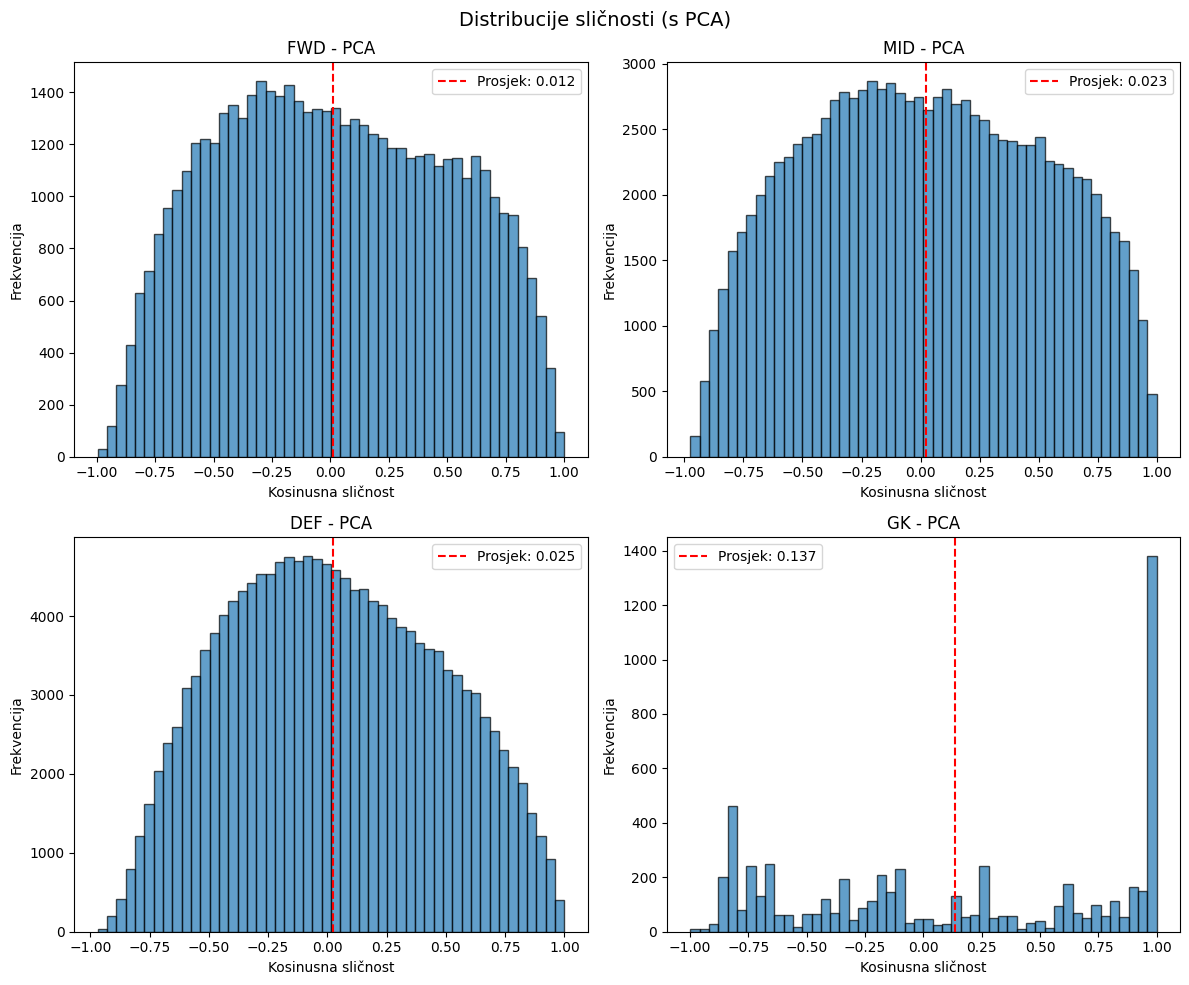


Sažetak distribucije sličnosti (s PCA):
FWD:
  Prosjek: 0.0124
  Std dev:  0.4817
  Min:  -0.9954
  Max:  0.9994
MID:
  Prosjek: 0.0225
  Std dev:  0.4915
  Min:  -0.9749
  Max:  0.9989
DEF:
  Prosjek: 0.0250
  Std dev:  0.4422
  Min:  -0.9685
  Max:  0.9993
GK:
  Prosjek: 0.1365
  Std dev:  0.6871
  Min:  -0.9990
  Max:  1.0000


In [47]:
# ----------------------------
# 8. Analiza distribucije sličnosti
# ----------------------------
import matplotlib.pyplot as plt

def analyze_similarity_distribution():
    """Analizirajte distribuciju rezultata sličnosti."""
    if not position_data:
        print("Nema dostupnih podataka o pozicijama.")
        return

    n_groups = len(position_data)
    n_cols = min(2, n_groups)
    n_rows = (n_groups + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))

    if n_groups == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_groups > 1 else [axes]

    for idx, (pos_group, data) in enumerate(position_data.items()):
        ax = axes[idx]
        sim_matrix = data['similarity_matrix']
        upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

        ax.hist(upper_triangle, bins=50, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Kosinusna sličnost')
        ax.set_ylabel('Frekvencija')
        ax.set_title(f'{pos_group} - PCA')
        ax.axvline(x=np.mean(upper_triangle), color='red', linestyle='--', label=f'Prosjek: {np.mean(upper_triangle):.3f}')
        ax.legend()

    for idx in range(n_groups, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Distribucije sličnosti (s PCA)', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nSažetak distribucije sličnosti (s PCA):")
    print("="*60)
    for pos_group, data in position_data.items():
        sim_matrix = data['similarity_matrix']
        upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        print(f"{pos_group}:")
        print(f"  Prosjek: {np.mean(upper_triangle):.4f}")
        print(f"  Std dev:  {np.std(upper_triangle):.4f}")
        print(f"  Min:  {np.min(upper_triangle):.4f}")
        print(f"  Max:  {np.max(upper_triangle):.4f}")

analyze_similarity_distribution()

In [48]:
# ----------------------------
# 9. Primjer:
# ----------------------------
find_similar_players("Nuno Mendes", n_similar=5)

Cilj: Nuno Mendes
Pozicija: DF (Grupa: DEF)
Klub: Paris S-G
Liga: fr Ligue 1
Dob: 23-198
--------------------------------------------------
Izračun sličnosti pomoću PCA značajki (8 komponenti).


,Player,Squad,Comp,Pos,Age,Similarity
0,Álex Grimaldo,Leverkusen,de Bundesliga,DF,30-105,0.985300
1,Josip Stanišić,Bayern Munich,de Bundesliga,DF,25-276,0.958178
2,Konrad Laimer,Bayern Munich,de Bundesliga,DF,28-221,0.931799
3,Nicola Zalewski,Atalanta,it Serie A,DF,23-345,0.927986
4,Musa Al-Taamari,Rennes,fr Ligue 1,"DF,FW",28-207,0.927113


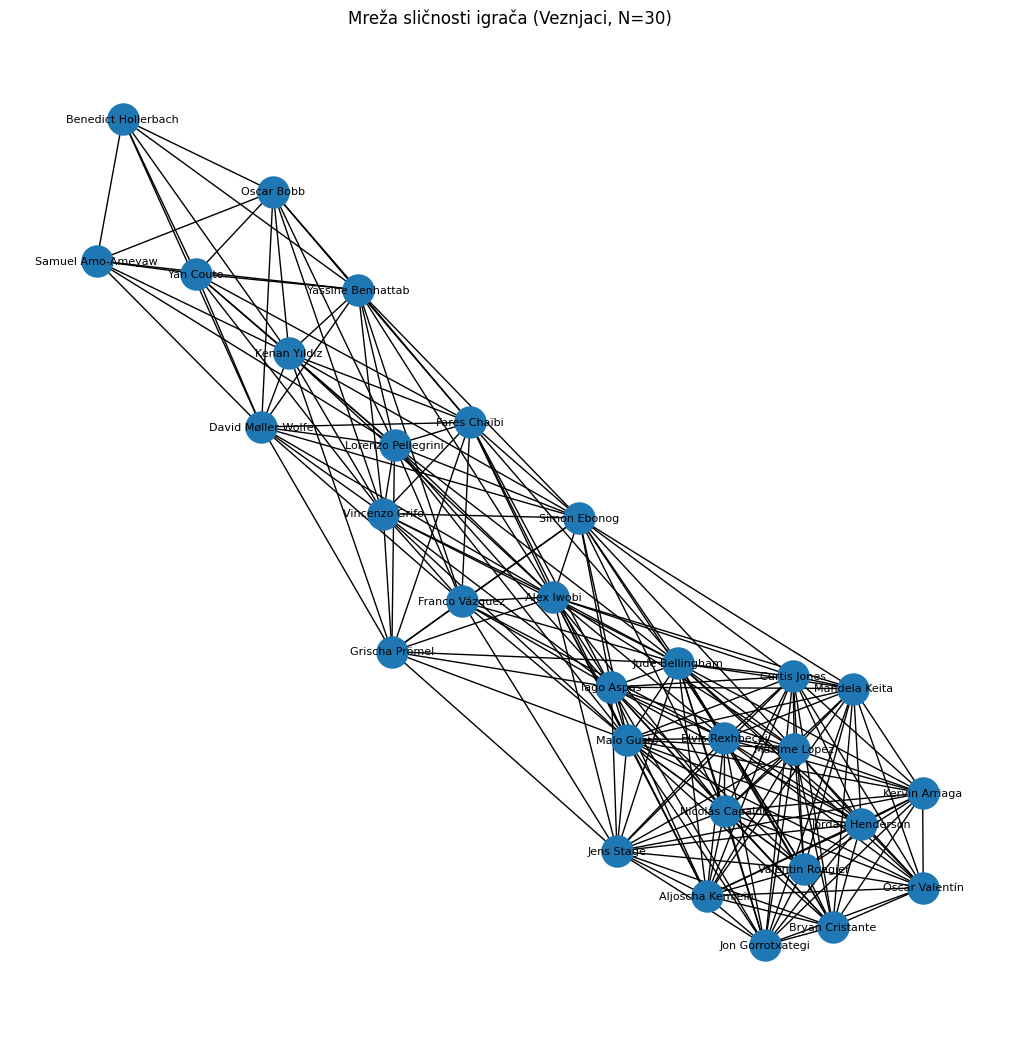

In [49]:
# ----------------------------
# 10. Vizualizacija mreže sličnosti
# ----------------------------
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# --- Konfiguracija veličine mreže ---
n_players_in_network = 30 # Broj igrača u mreži
# -------------------------------------

# Poduzorak igrača (primjer: napadači (FW))
df_pos = df[df["Pos"].str.contains("MF")].sample(n_players_in_network, random_state=10)

feature_cols = [c for c in df_pos.columns if c not in metadata_cols]
X = df_pos[feature_cols]

sim_matrix = cosine_similarity(X)

G = nx.Graph()

players = df_pos["Player"].values

# Dodajte bridove za visoku sličnost
threshold = 0.90
for i in range(len(players)):
    for j in range(i + 1, len(players)):
        if sim_matrix[i, j] > threshold:
            G.add_edge(players[i], players[j], weight=sim_matrix[i, j])

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)
plt.title(f"Mreža sličnosti igrača (Veznjaci, N={n_players_in_network})")
plt.show()

In [50]:
# ----------------------------
# 11. K-Means klasteriranje - funkcija
# ----------------------------
from sklearn.cluster import KMeans

def perform_kmeans_clustering(df, feature_cols, n_clusters):
    """
    Primjenjuje K-Means klasteriranje na DataFrame na temelju navedenih značajki.

    Args:
        df (pd.DataFrame): Ulazni DataFrame.
        feature_cols (list): Popis naziva stupaca koji će se koristiti kao značajke za klasteriranje.
        n_clusters (int): Željeni broj klastera.

    Returns:
        pd.DataFrame: DataFrame s dodanim stupcem 'Cluster' koji sadrži oznake klastera.
    """
    print(f"Izvođenje K-Means klasteriranja s {n_clusters} klastera...")
    # Inicijalizacija KMeans modela
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

    # Prilagodba modela navedenim značajkama i dodijela oznaka klasterima
    df['Cluster'] = kmeans.fit_predict(df[feature_cols])

    print("\nBroj igrača po klasteru:")
    print(df['Cluster'].value_counts().sort_index())
    print("\nKlasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.")

    return df

In [51]:
print("Primjena K-Means klasteriranja na navedene grupe pozicija...")

# 12. Primjena K-Means klasteriranja
n_clusters_map = {
    'FWD': 4,
    'MID': 4,
    'DEF': 3
}

# 2. Iteracija kroz position_data rječnik za navedene grupe
for pos_group, n_clusters in n_clusters_map.items():
    if pos_group in position_data:
        print(f"\n--- Klasteriranje za {pos_group} (n_clusters={n_clusters}) ---")
        # a. Dohvaćanje DataFrame za trenutnu pos_group
        df_to_cluster = position_data[pos_group]['df'].copy()
        # b. Dohvaćanje feature_cols za trenutnu pos_group
        # Napomena: feature_cols je već globalno definiran i ovdje je konzistentan među grupama.
        # Ako su potrebne specifične značajke po grupi, to bi bilo `position_data[pos_group]['features']`.
        current_feature_cols = feature_cols

        # d. Pozov funkcije perform_kmeans_clustering
        clustered_df = perform_kmeans_clustering(df_to_cluster, current_feature_cols, n_clusters)

        # e. Ažuriranje DataFrame unutar position_data
        position_data[pos_group]['df'] = clustered_df
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena u position_data. Preskače se.")

print("\nK-Means klasteriranje primijenjeno na FWD, MID i DEF grupe. Stupac 'Cluster' dodan u njihove DataFrames.")

Primjena K-Means klasteriranja na navedene grupe pozicija...

--- Klasteriranje za FWD (n_clusters=4) ---
Izvođenje K-Means klasteriranja s 4 klastera...

Broj igrača po klasteru:
Cluster
0     85
1     76
2     31
3    130
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

--- Klasteriranje za MID (n_clusters=4) ---
Izvođenje K-Means klasteriranja s 4 klastera...

Broj igrača po klasteru:
Cluster
0    253
1     87
2     16
3    111
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

--- Klasteriranje za DEF (n_clusters=3) ---
Izvođenje K-Means klasteriranja s 3 klastera...

Broj igrača po klasteru:
Cluster
0     55
1    119
2    385
Name: count, dtype: int64

Klasteriranje završeno. Stupac 'Cluster' dodan u DataFrame.

K-Means klasteriranje primijenjeno na FWD, MID i DEF grupe. Stupac 'Cluster' dodan u njihove DataFrames.


Vizualizacija distribucije igrača po klasterima...


/tmp/ipython-input-2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
/tmp/ipython-input-2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
/tmp/ipython-input-2665593259.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


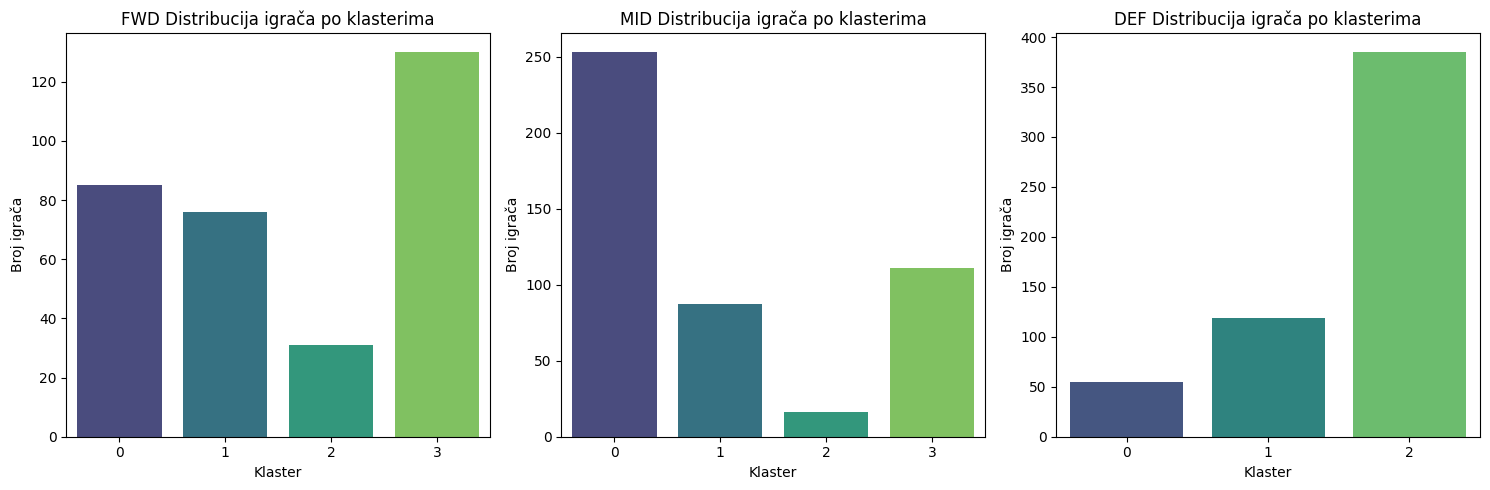

Vizualizacija distribucije igrača završena.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Vizualizacija distribucije igrača po klasterima...")

# ----------------------------
# 14. Vizualizacija distribucije klastera
# ----------------------------
# Definiranje grupe pozicija koje su klasterirane
clustered_pos_groups = ['FWD', 'MID', 'DEF']

plt.figure(figsize=(15, 5))

for i, pos_group in enumerate(clustered_pos_groups):
    if pos_group in position_data:
        df_clustered = position_data[pos_group]['df']

        # Broji igrače po klasteru
        cluster_counts = df_clustered['Cluster'].value_counts().sort_index()

        plt.subplot(1, len(clustered_pos_groups), i + 1)
        sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
        plt.title(f'{pos_group} Distribucija igrača po klasterima')
        plt.xlabel('Klaster')
        plt.ylabel('Broj igrača')
        plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Vizualizacija distribucije igrača završena.")

In [53]:
import random

# 15. Uzorkovanje igrača po klasterima
sample_players_to_highlight = {}

# 2. Definiranje popisa grupa pozicija za iteraciju
clustered_pos_groups_for_sampling = ['FWD', 'MID', 'DEF']

print("Uzorkovanje igrača iz svakog klastera za FWD, MID, DEF grupe...")

for pos_group in clustered_pos_groups_for_sampling:
    if pos_group in position_data:
        print(f"\n--- Uzorkovanje za {pos_group} ---")
        df_clustered = position_data[pos_group]['df']

        # 3. Iteracija kroz njegove jedinstvene ID-ove klastera
        unique_clusters = sorted(df_clustered['Cluster'].unique())

        sample_players_to_highlight[pos_group] = []

        for cluster_id in unique_clusters:
            print(f"  Klaster {cluster_id}:")
            # 4. Filtriranje DataFrame za igrače u ovom klasteru
            df_cluster = df_clustered[df_clustered['Cluster'] == cluster_id]

            # 5. Slučajno uzorkovanje do 5 igrača
            n_to_sample = min(len(df_cluster), 2)
            if n_to_sample > 0:
                # Odabir relevantnih stupaca za isticanje i pohrana
                sampled_players = df_cluster.sample(n=n_to_sample, random_state=42)[['Player', 'Squad', 'Pos', 'Cluster']].to_dict(orient='records')
                sample_players_to_highlight[pos_group].extend(sampled_players)

                # 7. Ispis imena odabranih igrača
                for player_info in sampled_players:
                    print(f"    - {player_info['Player']} ({player_info['Squad']}, {player_info['Pos']})")
            else:
                print("    (Nema igrača u ovom klasteru za uzorkovanje)")
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena ili nije klasterirana. Preskače se uzorkovanje.")

print("\nUzorkovanje igrača završeno. Uzorkovani igrači pohranjeni u 'sample_players_to_highlight'.")

Uzorkovanje igrača iz svakog klastera za FWD, MID, DEF grupe...

--- Uzorkovanje za FWD ---
  Klaster 0:
    - Willem Geubbels (Paris FC, FW)
    - Thiago (Brentford, FW)
  Klaster 1:
    - Leandro Trossard (Arsenal, FW)
    - Jack Grealish (Everton, FW)
  Klaster 2:
    - Sambou Soumano (Lorient, FW)
    - Raphinha (Barcelona, FW,MF)
  Klaster 3:
    - Martin Satriano (Lyon, FW)
    - Gustav Isaksen (Lazio, FW)

--- Uzorkovanje za MID ---
  Klaster 0:
    - Michel Ndary Adopo (Cagliari, MF)
    - Rassoul Ndiaye (Le Havre, MF)
  Klaster 1:
    - Senny Mayulu (Paris S-G, MF,FW)
    - Phil Foden (Manchester City, MF)
  Klaster 2:
    - Hakan Çalhanoğlu (Inter, MF)
    - Sofiane Diop (Nice, MF,FW)
  Klaster 3:
    - Lamine Camara (Monaco, MF)
    - Alex Iwobi (Fulham, MF,FW)

--- Uzorkovanje za DEF ---
  Klaster 0:
    - Pervis Estupiñán (Milan, DF)
    - Abner (Lyon, DF)
  Klaster 1:
    - Matheus Nunes (Manchester City, DF)
    - Sael Kumbedi (Wolfsburg, DF)
  Klaster 2:
    - Gerard Ma

In [54]:
from sklearn.manifold import TSNE

print("Primjena t-SNE redukcije dimenzionalnosti na značajke FWD, MID i DEF...")

# ----------------------------
# 16. t-SNE redukcija dimenzionalnosti
# ----------------------------
# Definiranje grupe pozicija za primjenu t-SNE
tsne_pos_groups = ['FWD', 'MID', 'DEF']

for pos_group in tsne_pos_groups:
    if pos_group in position_data:
        print(f"\n--- Primjena t-SNE za {pos_group} ---")
        # Dohvaćanje PCA značajke za trenutnu grupu pozicija
        pca_features = position_data[pos_group]['pca_features']

        # Inicijalizacija t-SNE model
        # n_components=2 za 2D vizualizaciju
        # random_state za ponovljivost
        # perplexity je ključni parametar, često se podešava. Zadana vrijednost je 30.
        # n_iter je broj iteracija. Zadana vrijednost je 1000.
        tsne = TSNE(n_components=2, random_state=42, perplexity=10, n_iter=1000)

        # Prilagodba i transformacija pca značajke u 2D
        tsne_results = tsne.fit_transform(pca_features)

        # Dodavanje t-SNE rezultata u position_data rječnik
        position_data[pos_group]['tsne_2d'] = tsne_results
        print(f"t-SNE redukcija dimenzionalnosti završena za {pos_group}. Oblik: {tsne_results.shape}")
    else:
        print(f"Upozorenje: Grupa pozicija '{pos_group}' nije pronađena u position_data. Preskače se t-SNE.")

print("\nt-SNE redukcija dimenzionalnosti primijenjena na navedene grupe pozicija.")

Primjena t-SNE redukcije dimenzionalnosti na značajke FWD, MID i DEF...

--- Primjena t-SNE za FWD ---


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE redukcija dimenzionalnosti završena za FWD. Oblik: (322, 2)

--- Primjena t-SNE za MID ---


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE redukcija dimenzionalnosti završena za MID. Oblik: (467, 2)

--- Primjena t-SNE za DEF ---


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE redukcija dimenzionalnosti završena za DEF. Oblik: (559, 2)

t-SNE redukcija dimenzionalnosti primijenjena na navedene grupe pozicija.


Generiranje t-SNE raspršenih dijagrama za FWD, MID i DEF...


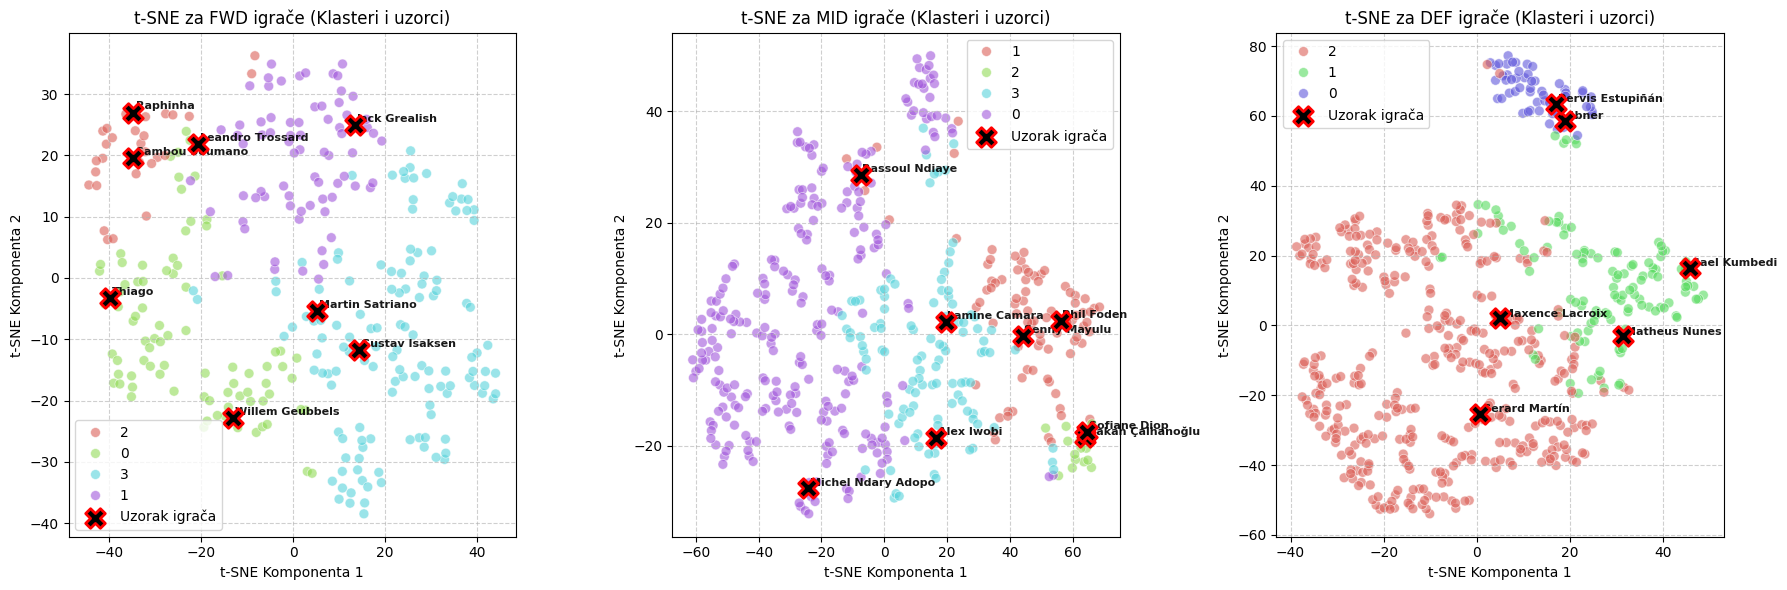

t-SNE raspršeni dijagrami generirani.


In [55]:
# ----------------------------
# 17. Vizualizacija t-SNE
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

print("Generiranje t-SNE raspršenih dijagrama za FWD, MID i DEF...")

tsne_pos_groups_to_plot = ['FWD', 'MID', 'DEF']

plt.figure(figsize=(18, 6))

for i, pos_group in enumerate(tsne_pos_groups_to_plot):
    if pos_group in position_data and 'tsne_2d' in position_data[pos_group] and 'df' in position_data[pos_group]:
        ax = plt.subplot(1, len(tsne_pos_groups_to_plot), i + 1)

        df_clustered = position_data[pos_group]['df']
        tsne_coords = position_data[pos_group]['tsne_2d']

        # Stvaranje privremenog DataFrame za crtanje
        plot_df = pd.DataFrame({
            'tsne-2d-jedan': tsne_coords[:, 0],
            'tsne-2d-dva': tsne_coords[:, 1],
            'Klaster': df_clustered['Cluster'].astype(str), # Pretvori u string za kategoričko bojanje
            'Igrač': df_clustered['Player'],
            'Klub': df_clustered['Squad']
        })

        # Nacrta sve igrače, obojene po klasteru
        sns.scatterplot(
            x="tsne-2d-jedan", y="tsne-2d-dva",
            hue="Klaster",
            palette=sns.color_palette("hls", df_clustered['Cluster'].nunique()),
            data=plot_df,
            legend="full",
            alpha=0.6,
            s=50, # veličina točaka
            ax=ax
        )

        # Istakne uzorkovane igrače
        highlight_players_list = sample_players_to_highlight.get(pos_group, [])
        if highlight_players_list:
            highlight_names = [p['Player'] for p in highlight_players_list]
            highlight_squads = [p['Squad'] for p in highlight_players_list]

            # Filtriranje plot_df da bi se dobile koordinate istaknutih igrača
            df_highlight = plot_df[plot_df['Igrač'].isin(highlight_names) & plot_df['Klub'].isin(highlight_squads)].copy()

            # Nacrta istaknute igrače s različitim markerom i većom veličinom
            sns.scatterplot(
                x="tsne-2d-jedan", y="tsne-2d-dva",
                data=df_highlight,
                marker='X', # Koristi 'X' za istaknute igrače
                s=200, # Veća veličina
                color='black', # Različita boja
                edgecolor='red', # Crveni obrub
                linewidth=2,
                label='Uzorak igrača',
                ax=ax,
                zorder=5 # Osigurava da su istaknuti igrači na vrhu
            )
            # Dodavanje bilješki za istaknute igrače
            for _, row in df_highlight.iterrows():
                ax.text(
                    row['tsne-2d-jedan'] + 0.5, row['tsne-2d-dva'] + 0.5,
                    f"{row['Igrač']}",
                    fontsize=8,
                    alpha=0.9,
                    color='black',
                    weight='bold'
                )

        ax.set_title(f't-SNE za {pos_group} igrače (Klasteri i uzorci)')
        ax.set_xlabel('t-SNE Komponenta 1')
        ax.set_ylabel('t-SNE Komponenta 2')
        ax.grid(True, linestyle='--', alpha=0.6)

    else:
        print(f"Upozorenje: Potrebni podaci za '{pos_group}' nisu pronađeni. Preskače se crtanje.")

plt.tight_layout()
plt.show()

print("t-SNE raspršeni dijagrami generirani.")

# Faza 3: Usporedna analiza metrika

U ovom dijelu sustavno uspoređujemo četiri metrike sličnosti (`cosine`, `euclidean`,
`dot_product`, `soft_cosine`) kroz nekoliko komplementarnih analiza:

- **A) Slaganje metoda** — koliko se metrike međusobno slažu (Jaccard@10 i Spearman).
- **B) Studije slučaja** — top-5 sličnih za izabrane igrače reprezentativnih profila.
- **C) Proxy ground-truth** — precision@5/@10 prema poziciji i K-Means klasteru.
- **D) Stabilnost** — otpornost top-lista na bootstrap i izbacivanje značajke.

Glavna os razlike među metrikama je **smjer profila** (kosinus, soft-kosinus → *stil* igre)
nasuprot **magnitudi** (euklid, skalarni produkt → *razina* doprinosa).

## A) Slaganje metoda

Mjerimo koliko se metrike međusobno slažu, na dvije razine:

- **Jaccard@10** — preklapanje skupova *top-10* najsličnijih igrača (fokus na vrh liste,
  ono što skaut zapravo gleda).
- **Spearman** — rang-korelacija *cijelog* poretka susjeda (fokus na ukupno slaganje).

Za svakog igrača računamo obje mjere za svaki par metrika, pa ih prosječimo preko svih
1243 igrača (sličnost se uvijek računa unutar pozicijske grupe). Rezultat su dvije
matrice 4×4 prikazane kao toplinske karte.

In [ ]:
# ----------------------------
# 3A. Slaganje metoda: Jaccard@10 (vrh liste) i Spearman (cijelo rangiranje)
# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata

metric_names = list(METRICS)
K = 10


def _pair_score_matrix(X, metric, M=None):
    """N×N matrica sličnosti gdje je VEĆE = sličnije.
    (euklid se vraća kao NEGATIVNA udaljenost, da orijentacija bude ista za sve.)"""
    if metric == 'cosine':
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        return Xn @ Xn.T
    if metric == 'dot_product':
        return X @ X.T
    if metric == 'euclidean':
        sq = np.sum(X ** 2, axis=1)
        d2 = sq[:, None] + sq[None, :] - 2 * (X @ X.T)
        return -np.sqrt(np.clip(d2, 0, None))
    if metric == 'soft_cosine':
        G = X @ M @ X.T
        nrm = np.sqrt(np.clip(np.diag(G), 1e-12, None))
        return G / np.outer(nrm, nrm)
    raise ValueError(metric)


def _avg_rowwise_pearson(A, B):
    """Prosječni Pearson po retku; na rangovima je to Spearman."""
    A = A - A.mean(1, keepdims=True)
    B = B - B.mean(1, keepdims=True)
    num = (A * B).sum(1)
    den = np.sqrt((A ** 2).sum(1) * (B ** 2).sum(1)) + 1e-12
    return (num / den).mean()


jac_sum = np.zeros((4, 4))
spe_sum = np.zeros((4, 4))
n_total = 0

# Akumuliramo preko svih igrača svih grupa (sličnost se uvijek računa unutar grupe).
for pg, data in position_data.items():
    X, M = data['std_features'], data['M']
    n = len(X)
    S = {m: _pair_score_matrix(X, m, M) for m in metric_names}
    topk, ranks = {}, {}
    for m in metric_names:
        Sm = S[m].copy()
        np.fill_diagonal(Sm, -np.inf)                 # isključi samog igrača
        topk[m] = np.argsort(-Sm, axis=1)[:, :K]      # top-K susjedi
        R = np.empty((n, n - 1))
        for i in range(n):
            R[i] = rankdata(np.delete(S[m][i], i))    # rang ostalih (za Spearman)
        ranks[m] = R
    for a in range(4):
        for b in range(4):
            ma, mb = metric_names[a], metric_names[b]
            j = 0.0
            for i in range(n):
                A, B = set(topk[ma][i]), set(topk[mb][i])
                j += len(A & B) / len(A | B)
            jac_sum[a, b] += j
            spe_sum[a, b] += _avg_rowwise_pearson(ranks[ma], ranks[mb]) * n
    n_total += n

jaccard = pd.DataFrame(jac_sum / n_total, index=metric_names, columns=metric_names)
spearman = pd.DataFrame(spe_sum / n_total, index=metric_names, columns=metric_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, ax=axes[0])
axes[0].set_title("Prosječni Jaccard@10\n(preklapanje top-10 susjeda)")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1,
            square=True, ax=axes[1])
axes[1].set_title("Prosječni Spearman\n(slaganje cijelog rangiranja)")
plt.tight_layout()
plt.show()

print("Jaccard@10:\n", jaccard.round(3).to_string())
print("\nSpearman:\n", spearman.round(3).to_string())

### Tumačenje 3A

Dvije mjere slaganja daju **komplementarnu** sliku:

- **Jaccard@10 (vrh liste).** Tri "stilske" metrike (`cosine`, `euclidean`, `soft_cosine`)
  čine klaster (preklapanje ~0.46–0.60), dok je `dot_product` izrazit autsajder
  (~0.10–0.20 preklapanja s ostalima). Na samom vrhu liste magnituda potpuno preslaguje
  tko su najsličniji.
- **Spearman (cijelo rangiranje).** Ovdje je `dot_product` vrlo blizak `cosine`-u (~0.95)
  i `soft_cosine`-u (~0.89), dok je `euclidean` relativni autsajder (~0.68–0.78).

Ova naizgled proturječna slika zapravo je ključ: budući da je `dot_product = cosine ×
magnituda`, **globalni poredak** uglavnom prati smjer (visok Spearman s kosinusom), ali
**vrh liste** preuzimaju visoko-volumni igrači (nizak Jaccard). Obrnuto, `euclidean` se s
kutnim metrikama slaže **lokalno** (najbliži susjedi su slični i po kutu i po udaljenosti
→ sličan top-10), ali **globalno** odudara (udaljenost i kut se razilaze u repovima
→ niži Spearman).

**Zaključak:** izbor metrike najviše utječe na **vrh liste preporuka** (ono što skaut
zapravo gleda), gdje se `dot_product` (količina) jasno odvaja od triju metrika stila.
Soft-kosinus i obični kosinus najsličniji su par i na vrhu i u cijelom poretku.

## B) Studije slučaja

Promatramo četiri igrača namjerno odabrana po **različitim profilima**, tako da pokrivaju
obje osi razlike među metrikama:

| Igrač | Grupa | Profil | Dominantne značajke (z-score) |
|---|---|---|---|
| **Erling Haaland** | FWD | čisti strijelac (ekstremna magnituda) | G-PK ≈ npxG ≈ **+5.3**, ostalo ~0 |
| **Kevin De Bruyne** | MID | kreator (vođen kreacijom) | **xAG +1.51**, PrgP +1.77, golovi niski |
| **Achraf Hakimi** | DEF | ofenzivni bek (progresija) | **PrgR +3.80**, PrgP +1.71 |
| **Curtis Jones** | MID | box-to-box (čista progresija) | **PrgP +3.61**, PrgC +1.23, xAG −0.19 |

Za svakog igrača prikazujemo **top-5 najsličnijih po svakoj od četiri metrike** (jedan
stupac po metrici), pa se izravno vidi gdje se rangiranja razilaze.

In [ ]:
# ----------------------------
# 3B-1. Tablice top-5 sličnih: jedan stupac po metrici, za svakog ciljanog igrača
# ----------------------------
from IPython.display import display

case_players = ["Haaland", "De Bruyne", "Hakimi", "Curtis Jones"]


def _resolve_target(player_name):
    """Vrati (redak, pozicijska_grupa) za prvog igrača koji odgovara imenu."""
    for pg, data in position_data.items():
        m = data['df'][data['df']['Player'].str.contains(player_name, case=False, na=False)]
        if len(m) > 0:
            return m.iloc[0], pg
    return None, None


def case_study_table(player_name, n=5):
    """Tablica top-n najsličnijih igrača — jedan STUPAC po metrici."""
    cols = {}
    for met in METRICS:
        res = find_similar_players(player_name, metric=met, n_similar=n, verbose=False)
        cols[met] = list(res['Player'])
    return pd.DataFrame(cols, index=[f"{i}." for i in range(1, n + 1)])


for p in case_players:
    info, pg = _resolve_target(p)
    print(f"\nCILJ: {info['Player']}  |  {info['Pos']} ({pg})  |  {info['Squad']}")
    display(case_study_table(p))

In [ ]:
# ----------------------------
# 3B-2. Ključni test: kreator (De Bruyne) vs samo-progresor (Curtis Jones)
# ----------------------------
# Oba veznjaka imaju visok PrgP (DBV +1.77, Jones +3.61), ali se bitno razlikuju u
# KREACIJI (xAG: DBV +1.51 vs Jones -0.19). Pitanje: koja metrika ih svrstava blizu
# (gleda samo zajedničku progresiju), a koja ih razdvaja (uvažava kreaciju)?

def cross_rank(target, other_substr):
    """Za svaku metriku vrati rang i score igrača `other_substr` na potpunoj
    listi sličnih igraču `target` (unutar njegove pozicijske grupe)."""
    row = {}
    for met in METRICS:
        res = find_similar_players(target, metric=met, n_similar=10**9, verbose=False)
        names = list(res['Player'])
        hit = [i for i, nm in enumerate(names) if other_substr in nm]
        row[met] = (f"{hit[0] + 1}. (score {res['Score'].iloc[hit[0]]:.3f})"
                    if hit else "—")
    return row

n_mid = len(position_data['MID']['df'])
cross = pd.DataFrame({
    f"Curtis Jones u susjedstvu De Bruynea (/{n_mid})": cross_rank("De Bruyne", "Curtis Jones"),
    f"De Bruyne u susjedstvu Curtisa Jonesa (/{n_mid})": cross_rank("Curtis Jones", "De Bruyne"),
}).T
print("Rang (i sličnost) ciljanog igrača na listi onog drugog:")
display(cross)

In [ ]:
# ----------------------------
# 3B-3. Razlaganje euklidske udaljenosti De Bruyne ↔ Curtis Jones po značajkama
# ----------------------------
# Provjeravamo ŠTO točno razdvaja ovaj par: koliko svaka značajka doprinosi kvadratu
# euklidske udaljenosti, (z_DBV - z_Jones)^2, i koliki je njezin udio u ukupnoj sumi.

def _zvec(name):
    d = position_data['MID']['df']
    row = d[d['Player'].str.contains(name, case=False, na=False)].iloc[0]
    return row[feature_cols].astype(float)

z_dbv = _zvec("De Bruyne")
z_jon = _zvec("Curtis Jones")
contrib = (z_dbv - z_jon) ** 2
decomp = pd.DataFrame({
    "z_DBV": z_dbv.round(2),
    "z_Jones": z_jon.round(2),
    "(razlika)^2": contrib.round(3),
    "udio_%": (100 * contrib / contrib.sum()).round(1),
}).sort_values("(razlika)^2", ascending=False)

print(f"Euklidska udaljenost = {np.sqrt(contrib.sum()):.3f}  |  "
      f"norma(DBV) = {np.linalg.norm(z_dbv):.2f}  |  norma(Jones) = {np.linalg.norm(z_jon):.2f}")
display(decomp)

### Tumačenje: De Bruyne ↔ Curtis Jones (kreacija *i* magnituda)

Oba veznjaka imaju visok `PrgP`, ali se razlikuju u `xAG` (+1.51 vs −0.19). Rang drugoga
na listi sličnih (od 441 veznjaka):

| | cosine | euclidean | dot_product | soft_cosine |
|---|---|---|---|---|
| Jones kod De Bruynea | 23. | 119. | **13.** | 108. |
| De Bruyne kod Jonesa | 37. | 31. | 36. | 55. |

**Što ih zapravo razdvaja (razlaganje euklidske udaljenosti, prethodna ćelija):** najveći
doprinos daje `PrgP` (~41 %), pa tek onda `xAG` (~34 %); te dvije osi nose ~75 % udaljenosti.
Razdvajanje dakle **nije samo "kreacija"** — gotovo jednako doprinosi to što je Jones ukupno
*veći i ekstremniji* progresijski vektor (norma 4.06 vs 2.67; progresira čak i više od
De Bruynea). Kreacija (`xAG`) je drugi, ne jedini, izvor razlike.

**Zašto je tablica asimetrična:** Jones je ekstreman vektor u rijetkom dijelu prostora. Iz
gustog susjedstva De Bruynea on je outlier (119.), dok je iz Jonesovog rijetkog susjedstva
De Bruyne tek jedan od mnogih umjerenih veznjaka (31.). Asimetrija je posljedica
**magnitude/gustoće**, što dodatno potvrđuje da odvajanje nije čisto stvar kreacije.

**Kako metrike reagiraju:**
- `cosine` ih drži blizu — smjer profila im se preklapa (oba progresijski nagnuti).
- `dot_product` ih drži NAJBLIže. To **nije pogreška**: skalarni produkt odgovara na *drugo
  pitanje* — "slične akcije u sličnoj **količini**". Za skauting (npr. traženje jednako
  *produktivne* zamjene, a ne nužno istog stila) to je legitiman kriterij, samo ne mjeri stil.
- `euclidean` i `soft_cosine` ih razdvajaju — osjetljivi su na cijeli profil, pa hvataju i
  razliku u volumenu progresije i u kreaciji.

**Zaključak:** par De Bruyne ↔ Jones pokazuje da metrike mjere *različita pitanja* (smjer/stil
nasuprot količini/magnitudi), ali **nije čist test "samo kreacije"**: njihovo odvajanje
kombinira razliku u kreaciji (`xAG`, ~34 %) i u ukupnoj magnitudi progresijskog profila
(`PrgP`, ~41 %).